In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype

from graficadores.histogramas import plot_histograma

In [27]:
data = pd.read_csv("./data/diabetic_data.csv")
admission_types_mapping = pd.read_csv("./data/admission_type_id_mapping.csv")
admission_source_mapping = pd.read_csv("./data/admission_source_id_mapping.csv")
discharge_disposition_mapping = pd.read_csv("./data/discharge_disposition_id_mapping.csv")

In [28]:
data.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [10]:
data = pd.merge(data,admission_types_mapping,how="left", on="admission_type_id")
data = pd.merge(data,admission_source_mapping,how="left", on="admission_source_id")
data = pd.merge(data,discharge_disposition_mapping,how="left", on="discharge_disposition_id")
data

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type_description,admission_source_description,discharge_disposition_description
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,NO,NaN,Physician Referral,Not Mapped
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,No,No,No,Ch,Yes,>30,Emergency,Emergency Room,Discharged to home
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,Yes,NO,Emergency,Emergency Room,Discharged to home
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,No,No,No,Ch,Yes,NO,Emergency,Emergency Room,Discharged to home
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,No,No,No,Ch,Yes,NO,Emergency,Emergency Room,Discharged to home
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,No,No,No,Ch,Yes,>30,Emergency,Emergency Room,Discharged/transferred to SNF
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,No,No,No,No,Yes,NO,Emergency,Transfer from a Skilled Nursing Facility (SNF),Discharged/transferred to ICF
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,No,No,No,Ch,Yes,NO,Emergency,Emergency Room,Discharged to home
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,No,No,No,Ch,Yes,NO,Urgent,Emergency Room,Discharged/transferred to SNF


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   encounter_id                       101766 non-null  int64 
 1   patient_nbr                        101766 non-null  int64 
 2   race                               101766 non-null  object
 3   gender                             101766 non-null  object
 4   age                                101766 non-null  object
 5   weight                             101766 non-null  object
 6   admission_type_id                  101766 non-null  int64 
 7   discharge_disposition_id           101766 non-null  int64 
 8   admission_source_id                101766 non-null  int64 
 9   time_in_hospital                   101766 non-null  int64 
 10  payer_code                         101766 non-null  object
 11  medical_specialty                  101766 non-null  

## Análisis de edad

In [12]:
data.weight.value_counts()
data["is_older_40"] = data["age"].apply(lambda age: 1 if age not in ["[0-10)","[10-20)", "[20-30)", "[30-40)"] else 0)
data["is_older_40"].value_counts(normalize=True)

is_older_40
1    0.93825
0    0.06175
Name: proportion, dtype: float64

In [13]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
categories = data.age.astype(CategoricalDtype(categories=age_order,ordered=True))
categories_map = {code:cat for code,cat in zip(categories.cat.codes,categories.cat.categories)}

categories_map.get(categories.cat.codes.median())

'[60-70)'

In [14]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from graficadores.histogramas import cuartiles

# plt.figure(figsize=(10, 5))
# ax = sns.histplot(data=data, x="age")
# q1_idx, q2_idx, q3_idx = cuartiles(data["age"].cat.codes)
# plt.title("Histograma de edad por cuartiles")
# plt.xlabel("Edad")
# plt.ylabel("Pacientes")
# plt.axvline(x=q1_idx, label=f"Q1 (25%): {categories_map.get(int(round(q1_idx)))}", linestyle="--")
# plt.axvline(x=q2_idx, label=f"Mediana (50%): {categories_map.get(int(round(q2_idx)))}")
# plt.axvline(x=q3_idx, label=f"Q3 (75%): {categories_map.get(int(round(q3_idx)))}", linestyle="--")
# plt.legend(frameon=True)
# plt.show()


---

In [15]:
data.gender.value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [16]:
data.readmitted.value_counts(normalize=True)

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

### Recategorizaciones

In [17]:
data["diabetesMed"] = data["diabetesMed"].apply(lambda x: 1 if x == "Yes" else 0)
data["change"] = data["change"].apply(lambda x: 1 if x == "Ch" else 0)
data["max_glucosa_normalizada"] = data['max_glu_serum'].dropna().apply(lambda x: 1 if x in [">200",">300"] else 0)
data.groupby("readmitted")["diabetesMed"].sum()

readmitted
<30     9111
>30    28318
NO     40934
Name: diabetesMed, dtype: int64

In [18]:
data.groupby("readmitted")["change"].value_counts(normalize=True)

readmitted  change
<30         0         0.510610
            1         0.489390
>30         0         0.514081
            1         0.485919
NO          0         0.559256
            1         0.440744
Name: proportion, dtype: float64

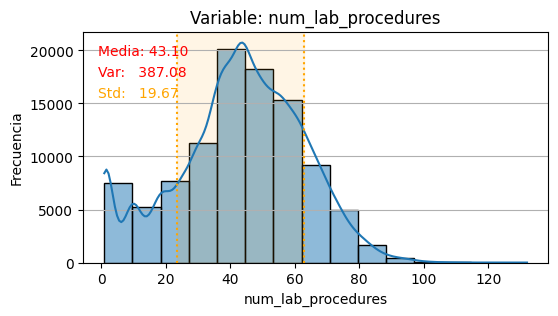

In [19]:
data["num_medications"].mean(),data["num_medications"].median()
# Función para graficar

plot_histograma(data,"num_lab_procedures")

In [20]:
pd.qcut(data["num_lab_procedures"],q=4).value_counts().sort_index()

num_lab_procedures
(0.999, 31.0]    25512
(31.0, 44.0]     26303
(44.0, 57.0]     25594
(57.0, 132.0]    24357
Name: count, dtype: int64

In [21]:
data["num_procedures"].value_counts(normalize=True)

num_procedures
0    0.458424
1    0.203821
2    0.124963
3    0.092791
6    0.048680
4    0.041075
5    0.030246
Name: proportion, dtype: float64

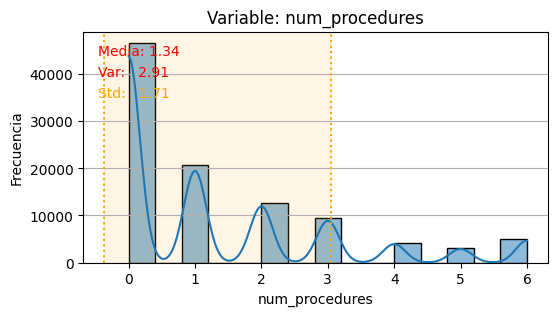

In [22]:
plot_histograma(data,"num_procedures")

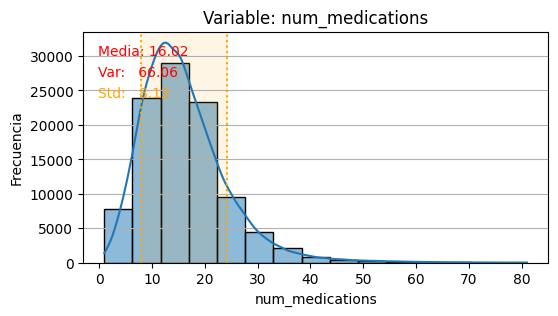

In [23]:
plot_histograma(data,"num_medications")

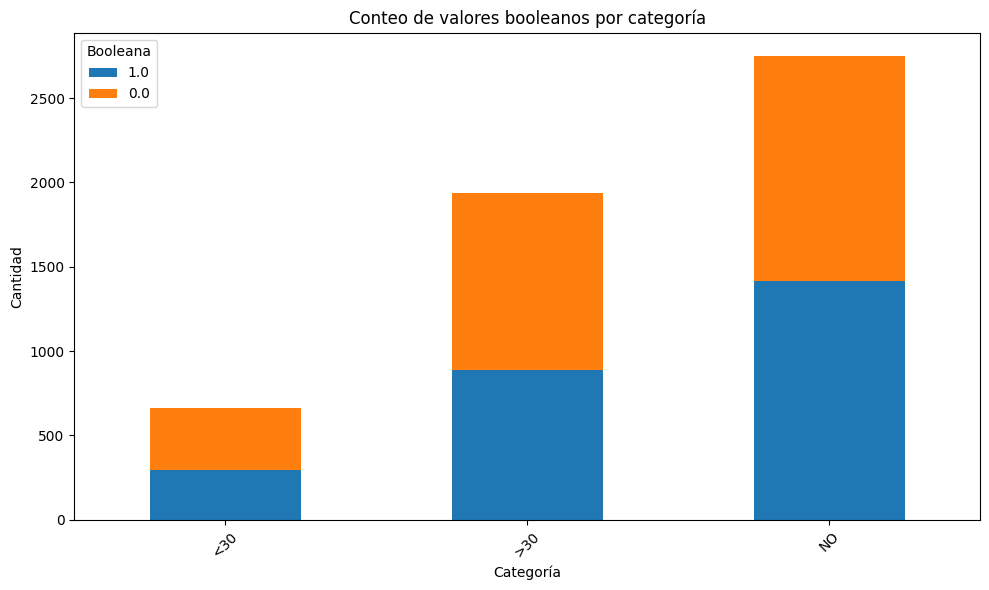

In [24]:


cross = pd.crosstab(data['readmitted'], data['max_glucosa_normalizada'].dropna())
cross.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Conteo de valores booleanos por categoría')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.legend(title='Booleana', labels=data['max_glucosa_normalizada'].dropna().unique())
plt.tight_layout()
plt.show()

### Gráficos de torta de variables administrativas

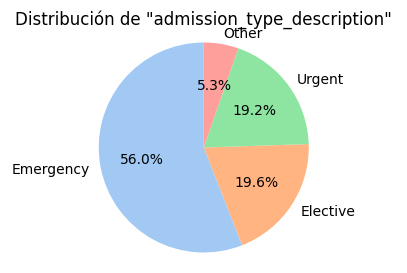

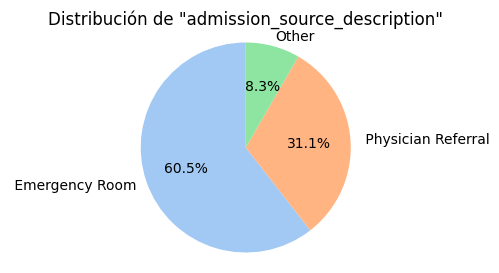

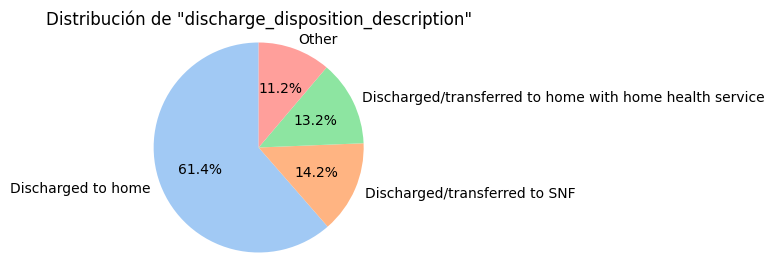

In [25]:
from graficadores.histogramas import plot_pie

plot_pie(data, "admission_type_description")
plot_pie(data, "admission_source_description")
plot_pie(data, "discharge_disposition_description")


### glucosa y medicacion

In [26]:
data["max_glu_serum"].value_counts()

max_glu_serum
Norm    2597
>200    1485
>300    1264
Name: count, dtype: int64